In [41]:
# # One Dataset, Different Questions
# ## What ML Can (and Cannot) Tell MOF Chemists About CO₂ Adsorption
# 
# Reproducing and extending: Li, X., et al. (2023). *Carbon Capture Science & Technology*, 9, 100146.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Notebook initialized.")

Notebook initialized.


In [42]:
# ## 1. Load and Prepare Data

df = pd.read_csv('Table_S3.csv', encoding='latin1')
df = df.dropna(how='all')
df = df.rename(columns={
    'SBET(m2/g)': 'S_BET', 'SL(m2/g)': 'S_L', 'VT(cm3/g)': 'V_T',
    'P(kPa)': 'P_kPa', 'T(K)': 'T_K', 'Mental center': 'Metal',
    'Uptake': 'Uptake_mmol_g'
})
df['Sample'] = df['Sample'].ffill()
df['Metal'] = df['Metal'].str.strip()
df = df.dropna(subset=['Uptake_mmol_g'])

print(f"Dataset: {len(df)} samples")
print(f"Pressure: {df['P_kPa'].min():.0f} – {df['P_kPa'].max():.0f} kPa")
print(f"Temperature: {df['T_K'].min():.0f} – {df['T_K'].max():.0f} K")
print(f"Metals: {sorted(df['Metal'].unique())}")

Dataset: 348 samples
Pressure: 10 – 4600 kPa
Temperature: 195 – 313 K
Metals: ['Al', 'Cd', 'Co', 'Cu', 'Fe', 'Hf', 'Ni', 'Ti', 'Zn', 'Zr']


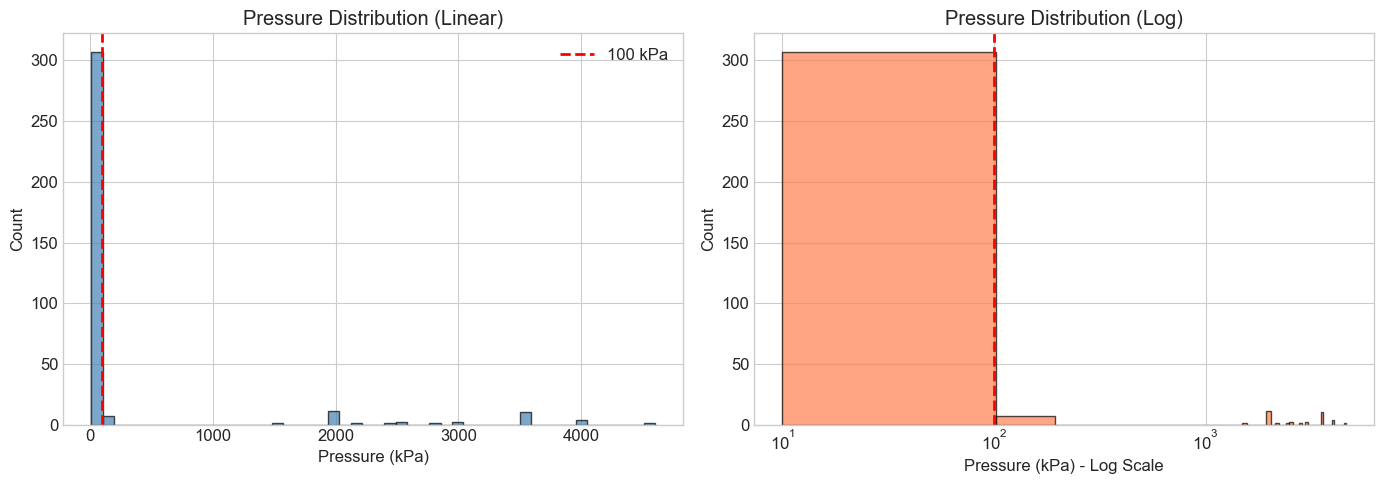

Low Pressure (≤100 kPa):  294 samples
High Pressure (>100 kPa): 54 samples


In [43]:
# ## 2. Pressure Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['P_kPa'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=100, color='red', linestyle='--', linewidth=2, label='100 kPa')
axes[0].set_xlabel('Pressure (kPa)'); axes[0].set_ylabel('Count')
axes[0].set_title('Pressure Distribution (Linear)'); axes[0].legend()

axes[1].hist(df['P_kPa'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(x=100, color='red', linestyle='--', linewidth=2)
axes[1].set_xscale('log'); axes[1].set_xlabel('Pressure (kPa) - Log Scale')
axes[1].set_ylabel('Count'); axes[1].set_title('Pressure Distribution (Log)')

plt.tight_layout()
plt.savefig('pressure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Count by regime
print(f"Low Pressure (≤100 kPa):  {len(df[df['P_kPa'] <= 100])} samples")
print(f"High Pressure (>100 kPa): {len(df[df['P_kPa'] > 100])} samples")

In [44]:
# ## 3. Reproduce Original Model (Li et al.)

metal_encoded = pd.get_dummies(df['Metal'], prefix='Metal')
X_full = pd.concat([df[['S_BET', 'S_L', 'V_T', 'P_kPa', 'T_K']], metal_encoded], axis=1)
y = df['Uptake_mmol_g']

X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.15, random_state=42)

rf_full = RandomForestRegressor(n_estimators=87, max_depth=11, random_state=58, n_jobs=-1)
rf_full.fit(X_train, y_train)

train_r2 = rf_full.score(X_train, y_train)
test_r2 = r2_score(y_test, rf_full.predict(X_test))
test_rmse = np.sqrt(mean_squared_error(y_test, rf_full.predict(X_test)))

print(f"Train R²: {train_r2:.4f}  (Li et al.: 0.970)")
print(f"Test R²:  {test_r2:.4f}  (Li et al.: 0.896)")
print(f"Test RMSE: {test_rmse:.4f} mmol/g")

# Feature importance
imp_full = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance': rf_full.feature_importances_
}).sort_values('Importance', ascending=False)

pt_imp = imp_full[imp_full['Feature'].isin(['P_kPa', 'T_K'])]['Importance'].sum()
print(f"\nP + T importance: {pt_imp*100:.1f}%")

Train R²: 0.9761  (Li et al.: 0.970)
Test R²:  0.7521  (Li et al.: 0.896)
Test RMSE: 2.0038 mmol/g

P + T importance: 76.5%


In [45]:
# ## 4. Remove Pressure and Temperature

X_mof = X_full.drop(['P_kPa', 'T_K'], axis=1)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mof, y, test_size=0.15, random_state=42
)

rf_mof = RandomForestRegressor(n_estimators=87, max_depth=11, random_state=58, n_jobs=-1)
rf_mof.fit(X_train_m, y_train_m)

r2_mof = r2_score(y_test_m, rf_mof.predict(X_test_m))
print(f"Full model R²:    {test_r2:.4f}")
print(f"Without P,T R²:   {r2_mof:.4f}")
print(f"Drop:             {test_r2 - r2_mof:.4f}")

Full model R²:    0.7521
Without P,T R²:   0.2792
Drop:             0.4729


In [46]:
# ## 5. Low-Pressure Model (≤100 kPa)

df_low = df[df['P_kPa'] <= 100].copy()
metal_low = pd.get_dummies(df_low['Metal'], prefix='Metal')
X_low = pd.concat([df_low[['S_BET', 'S_L', 'V_T']], metal_low], axis=1)
y_low = df_low['Uptake_mmol_g']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_low, y_low, test_size=0.20, random_state=42
)

rf_low = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=58, n_jobs=-1)
rf_low.fit(X_train_l, y_train_l)

train_r2_l = rf_low.score(X_train_l, y_train_l)
test_r2_l = r2_score(y_test_l, rf_low.predict(X_test_l))
rmse_l = np.sqrt(mean_squared_error(y_test_l, rf_low.predict(X_test_l)))

print(f"Low-Pressure Model (n={len(df_low)})")
print(f"Train R²: {train_r2_l:.4f}")
print(f"Test R²:  {test_r2_l:.4f}")
print(f"Test RMSE: {rmse_l:.4f} mmol/g")

imp_low = pd.DataFrame({
    'Feature': X_low.columns,
    'Importance': rf_low.feature_importances_
}).sort_values('Importance', ascending=False)

texture_l = imp_low[imp_low['Feature'].isin(['S_BET', 'S_L', 'V_T'])]['Importance'].sum()
metal_l = imp_low[imp_low['Feature'].str.startswith('Metal_')]['Importance'].sum()

print(f"\nTexture importance: {texture_l*100:.1f}%")
print(f"Metal importance:   {metal_l*100:.1f}%")
print(f"\nTop 5 features:")
for _, row in imp_low.head(5).iterrows():
    print(f"  {row['Feature']:<20}: {row['Importance']:.4f}")

Low-Pressure Model (n=294)
Train R²: 0.6871
Test R²:  0.2467
Test RMSE: 2.4819 mmol/g

Texture importance: 75.3%
Metal importance:   24.7%

Top 5 features:
  S_L                 : 0.2814
  V_T                 : 0.2603
  S_BET               : 0.2115
  Metal_Cu            : 0.1059
  Metal_Ni            : 0.0744


In [47]:
# ## 6. High-Pressure Model (>100 kPa)

df_high = df[df['P_kPa'] > 100].copy()
metal_high = pd.get_dummies(df_high['Metal'], prefix='Metal')
X_high = pd.concat([df_high[['S_BET', 'S_L', 'V_T']], metal_high], axis=1)
y_high = df_high['Uptake_mmol_g']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_high, y_high, test_size=0.25, random_state=42
)

rf_high = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=58, n_jobs=-1)
rf_high.fit(X_train_h, y_train_h)

train_r2_h = rf_high.score(X_train_h, y_train_h)
test_r2_h = r2_score(y_test_h, rf_high.predict(X_test_h))
rmse_h = np.sqrt(mean_squared_error(y_test_h, rf_high.predict(X_test_h)))

print(f"High-Pressure Model (n={len(df_high)})")
print(f"Train R²: {train_r2_h:.4f}")
print(f"Test R²:  {test_r2_h:.4f}")
print(f"Test RMSE: {rmse_h:.4f} mmol/g")

imp_high = pd.DataFrame({
    'Feature': X_high.columns,
    'Importance': rf_high.feature_importances_
}).sort_values('Importance', ascending=False)

texture_h = imp_high[imp_high['Feature'].isin(['S_BET', 'S_L', 'V_T'])]['Importance'].sum()
metal_h = imp_high[imp_high['Feature'].str.startswith('Metal_')]['Importance'].sum()

print(f"\nTexture importance: {texture_h*100:.1f}%")
print(f"Metal importance:   {metal_h*100:.1f}%")
print(f"\nTop 5 features:")
for _, row in imp_high.head(5).iterrows():
    print(f"  {row['Feature']:<20}: {row['Importance']:.4f}")

High-Pressure Model (n=54)
Train R²: 0.9464
Test R²:  -0.3160
Test RMSE: 6.8433 mmol/g

Texture importance: 94.2%
Metal importance:   5.8%

Top 5 features:
  S_L                 : 0.5417
  V_T                 : 0.2402
  S_BET               : 0.1603
  Metal_Cu            : 0.0225
  Metal_Ni            : 0.0158


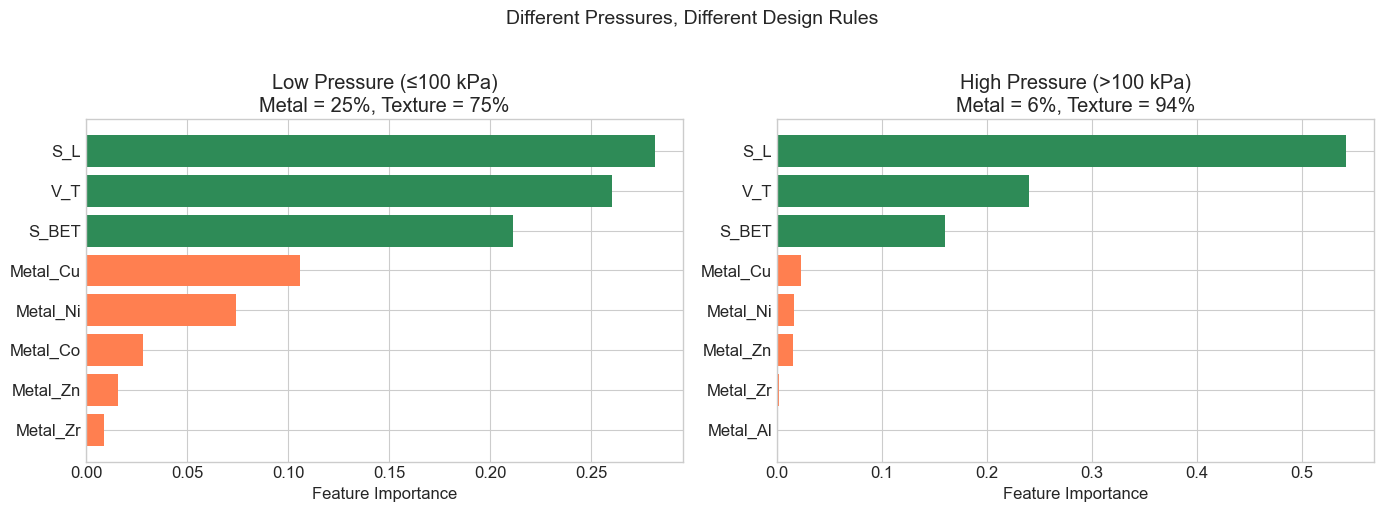

In [48]:
# ## 7. Comparison: What Matters at Different Pressures?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Low pressure
top_low = imp_low.head(8)
colors_low = ['seagreen' if f in ['S_BET', 'S_L', 'V_T'] else 'coral' for f in top_low['Feature']]
axes[0].barh(top_low['Feature'], top_low['Importance'], color=colors_low)
axes[0].set_title(f'Low Pressure (≤100 kPa)\nMetal = {metal_l*100:.0f}%, Texture = {texture_l*100:.0f}%')
axes[0].set_xlabel('Feature Importance')
axes[0].invert_yaxis()

# High pressure
top_high = imp_high.head(8)
colors_high = ['seagreen' if f in ['S_BET', 'S_L', 'V_T'] else 'coral' for f in top_high['Feature']]
axes[1].barh(top_high['Feature'], top_high['Importance'], color=colors_high)
axes[1].set_title(f'High Pressure (>100 kPa)\nMetal = {metal_h*100:.0f}%, Texture = {texture_h*100:.0f}%')
axes[1].set_xlabel('Feature Importance')
axes[1].invert_yaxis()

plt.suptitle('Different Pressures, Different Design Rules', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('regime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

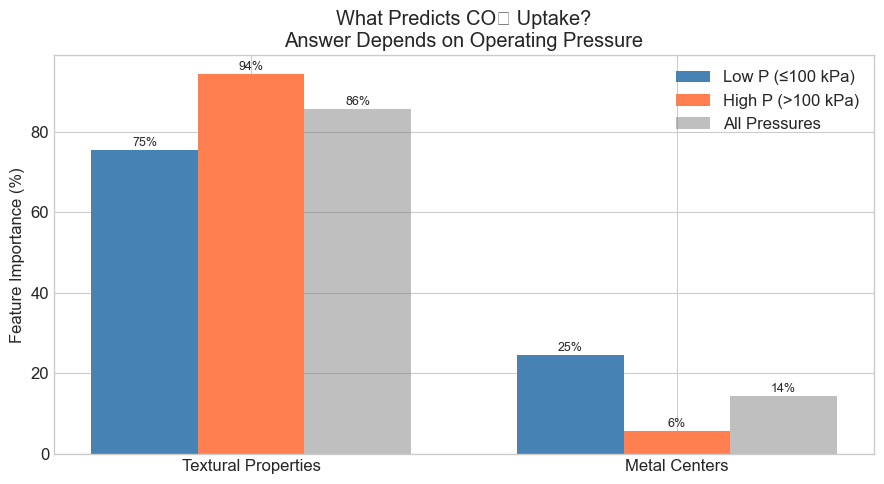

In [49]:
# ## 8. Three-Way Comparison

# Full model with MOF-only features
X_full_mof = pd.concat([df[['S_BET', 'S_L', 'V_T']], pd.get_dummies(df['Metal'], prefix='Metal')], axis=1)
rf_full_mof = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=58, n_jobs=-1)
rf_full_mof.fit(
    *train_test_split(X_full_mof, y, test_size=0.20, random_state=42)[::2]
)

imp_full_mof = pd.DataFrame({
    'Feature': X_full_mof.columns,
    'Importance': rf_full_mof.feature_importances_
})

texture_f = imp_full_mof[imp_full_mof['Feature'].isin(['S_BET', 'S_L', 'V_T'])]['Importance'].sum()
metal_f = imp_full_mof[imp_full_mof['Feature'].str.startswith('Metal_')]['Importance'].sum()

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(2)
width = 0.25

ax.bar(x - width, [texture_l*100, metal_l*100], width, label='Low P (≤100 kPa)', color='steelblue')
ax.bar(x,        [texture_h*100, metal_h*100], width, label='High P (>100 kPa)', color='coral')
ax.bar(x + width, [texture_f*100, metal_f*100], width, label='All Pressures', color='gray', alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(['Textural Properties', 'Metal Centers'])
ax.set_ylabel('Feature Importance (%)')
ax.set_title('What Predicts CO₂ Uptake?\nAnswer Depends on Operating Pressure')
ax.legend()

for bars in ax.containers:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('three_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# ## 9. Summary

print("="*60)
print("SUMMARY")
print("="*60)
print(f"Original model (with P,T):     R² = {test_r2:.3f}")
print(f"Without P and T:               R² = {r2_mof:.3f}")
print(f"Low-pressure only (≤100 kPa):  R² = {test_r2_l:.3f}  (metals = {metal_l*100:.0f}%)")
print(f"High-pressure only (>100 kPa): R² = {test_r2_h:.3f}  (metals = {metal_h*100:.0f}%)")
print()
print("Key Insight:")
print("  Metal identity is 4× more important at low pressure")
print("  than at high pressure (25% vs 6%).")
print()
print("Limitation:")
print("  These models do not predict uptake reliably.")
print("  A larger dataset is needed for accurate regime-specific models.")
print()
print("Lesson:")
print("  The question you ask determines the answer you get.")
print("  Different operating pressures → different design rules.")

SUMMARY
Original model (with P,T):     R² = 0.752
Without P and T:               R² = 0.279
Low-pressure only (≤100 kPa):  R² = 0.247  (metals = 25%)
High-pressure only (>100 kPa): R² = -0.316  (metals = 6%)

Key Insight:
  Metal identity is 4× more important at low pressure
  than at high pressure (25% vs 6%).

Limitation:
  These models do not predict uptake reliably.
  A larger dataset is needed for accurate regime-specific models.

Lesson:
  The question you ask determines the answer you get.
  Different operating pressures → different design rules.
